# GSE44076: Expression Preprocessing Check

This notebook checks the supplied series matrix before any PCA or differential analysis. It reviews the value scale, sample-level medians and interquartile ranges, and simple descriptive flags for unusually positioned samples.

No samples are removed. The checks do not replace platform-specific quality control or confirmation of the original preprocessing workflow.

## Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.geo_loader import (  # noqa: E402
    align_expression_with_metadata,
    build_sample_metadata_table,
    convert_expression_to_numeric,
    load_geo_expression_table,
    read_geo_series_lines,
    summarize_expression_values,
    summarize_sample_distributions,
)

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "GSE44076_series_matrix.txt.gz"
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "sample_metadata.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

GROUP_MAP = {
    "Healthy colon mucosa cells": "healthy_mucosa",
    "Normal distant colon mucosa cells": "paired_normal_mucosa",
    "Primary colon adenocarcinoma cells": "tumor",
}
GROUP_ORDER = ["healthy_mucosa", "paired_normal_mucosa", "tumor"]
GROUP_COLORS = {
    "healthy_mucosa": "#2A9D8F",
    "paired_normal_mucosa": "#E9C46A",
    "tumor": "#C8553D",
}

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## Load and Align the Matrix

The processed metadata table is loaded when present; otherwise, it is rebuilt from the GEO metadata. Expression columns are then aligned to metadata rows and converted to numeric values.

In [2]:
if not RAW_PATH.is_file():
    raise FileNotFoundError(
        "GSE44076 series matrix not found. Place the downloaded file at "
        f"{RAW_PATH}"
    )

expression = load_geo_expression_table(RAW_PATH)
if METADATA_PATH.is_file():
    sample_metadata = pd.read_csv(METADATA_PATH)
else:
    sample_metadata = build_sample_metadata_table(read_geo_series_lines(RAW_PATH))

if "group" not in sample_metadata:
    sample_metadata["group"] = sample_metadata["source_name"].map(GROUP_MAP)
if sample_metadata["group"].isna().any():
    raise ValueError("Some sample source names do not have a documented group label.")

expression, sample_metadata = align_expression_with_metadata(expression, sample_metadata)
expression = convert_expression_to_numeric(expression)
sample_columns = sample_metadata["sample_accession"].tolist()
expression_values = expression[sample_columns]

print(f"Aligned expression table: {expression.shape}")
print(f"Numeric matrix: {expression_values.shape}")
print(f"Missing numeric values: {int(expression_values.isna().sum().sum()):,}")

Aligned expression table: (49386, 247)
Numeric matrix: (49386, 246)
Missing numeric values: 0


## Value Range, Quantiles, and Distribution

The summaries below describe the values supplied by GEO. A compact continuous range can be consistent with transformed microarray values, but the transformation must still be confirmed from the dataset's processing notes.

In [3]:
expression_summary = summarize_expression_values(expression)
display(expression_summary.to_frame())

looks_log2_like = (
    expression_summary["minimum"] >= 0
    and expression_summary["maximum"] < 20
    and expression_summary["q99"] < 16
)
print(f"Simple scale check is consistent with log2-like values: {looks_log2_like}")
print("This is a descriptive heuristic, not confirmation of the original transformation.")

,expression_value
count,1.214896e+07
missing,0.000000e+00
minimum,1.416100e+00
q01,1.896900e+00
q05,2.078000e+00
q25,2.541800e+00
median,3.702500e+00
q75,6.319500e+00
q95,9.190900e+00
q99,1.122410e+01


Simple scale check is consistent with log2-like values: True
This is a descriptive heuristic, not confirmation of the original transformation.


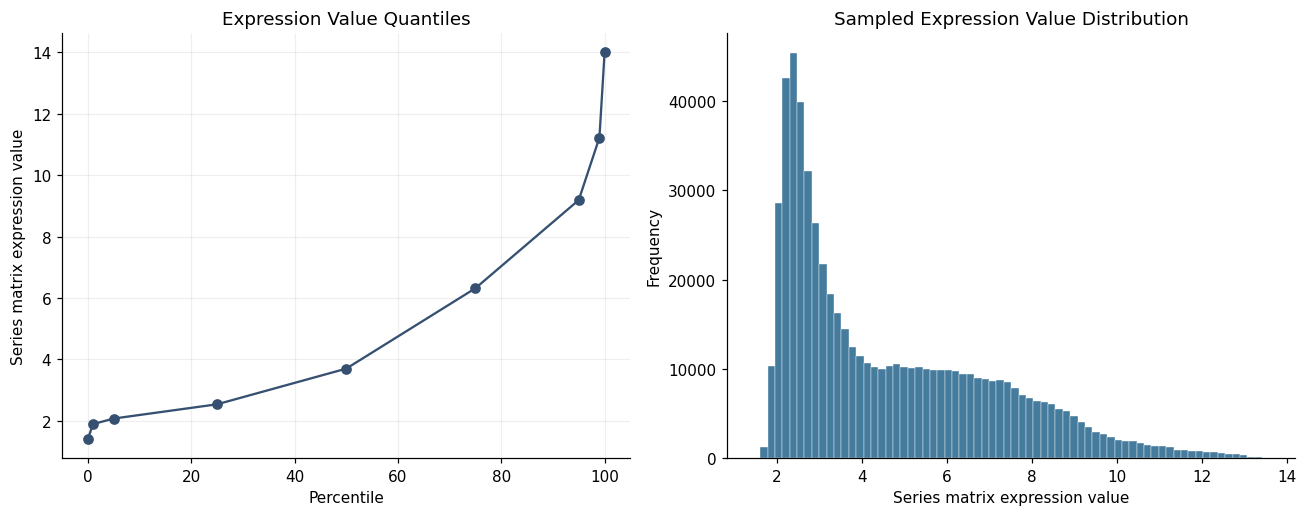

In [4]:
quantile_levels = np.array([0.00, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])
quantile_values = expression_values.stack().quantile(quantile_levels)
sampled_values = expression_values.iloc[::20].to_numpy().ravel()
sampled_values = sampled_values[~np.isnan(sampled_values)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(quantile_levels * 100, quantile_values.values, marker="o", color="#355070")
axes[0].set_title("Expression Value Quantiles")
axes[0].set_xlabel("Percentile")
axes[0].set_ylabel("Series matrix expression value")
axes[0].grid(alpha=0.2)

axes[1].hist(sampled_values, bins=70, color="#457B9D", edgecolor="white", linewidth=0.25)
axes[1].set_title("Sampled Expression Value Distribution")
axes[1].set_xlabel("Series matrix expression value")
axes[1].set_ylabel("Frequency")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "expression_quantiles.png", dpi=180, bbox_inches="tight")
plt.show()

## Per-Sample Median and IQR

Medians summarize each sample's overall location, while IQRs summarize its central spread. Similar values across most samples would support a first exploratory comparison, although they do not establish full normalization or data quality.

In [5]:
sample_summary = summarize_sample_distributions(expression).join(
    sample_metadata.set_index("sample_accession")[["group", "title"]]
)
display(sample_summary[["median", "iqr", "minimum", "maximum", "missing"]].describe())

,median,iqr,minimum,maximum,missing
count,246.000000,246.000000,246.000000,246.000000,246.0
mean,3.704411,3.776902,1.563820,13.790194,0.0
std,0.042432,0.099308,0.048871,0.115321,0.0
min,3.504050,3.281750,1.416100,13.407300,0.0
25%,3.673763,3.730150,1.535225,13.721150,0.0
50%,3.704075,3.783662,1.564300,13.834100,0.0
75%,3.731425,3.851288,1.597050,13.869500,0.0
max,3.816500,3.955625,1.685200,13.993700,0.0


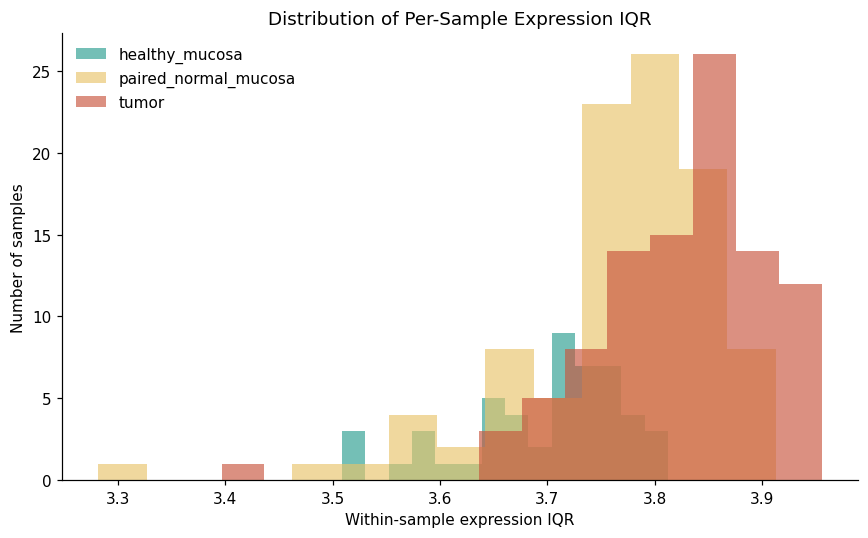

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for group in GROUP_ORDER:
    group_iqr = sample_summary.loc[sample_summary["group"] == group, "iqr"]
    ax.hist(group_iqr, bins=14, alpha=0.65, color=GROUP_COLORS[group], label=group)

ax.set_title("Distribution of Per-Sample Expression IQR")
ax.set_xlabel("Within-sample expression IQR")
ax.set_ylabel("Number of samples")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sample_iqr_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## Descriptive Extreme-Sample Flags

A sample is flagged when its median or IQR falls outside 1.5 times the across-sample IQR from the corresponding quartiles. This rule is a screening device only: flagged samples remain in the matrix and require contextual review before any decision.

In [7]:
def tukey_fences(values):
    lower_quartile, upper_quartile = values.quantile([0.25, 0.75])
    spread = upper_quartile - lower_quartile
    return lower_quartile - 1.5 * spread, upper_quartile + 1.5 * spread


median_lower, median_upper = tukey_fences(sample_summary["median"])
iqr_lower, iqr_upper = tukey_fences(sample_summary["iqr"])

sample_summary["median_flag"] = ~sample_summary["median"].between(median_lower, median_upper)
sample_summary["iqr_flag"] = ~sample_summary["iqr"].between(iqr_lower, iqr_upper)
sample_summary["descriptive_flag"] = sample_summary[["median_flag", "iqr_flag"]].any(axis=1)

flagged_samples = sample_summary.loc[
    sample_summary["descriptive_flag"],
    ["median", "iqr", "median_flag", "iqr_flag", "group", "title"],
].sort_values(["median_flag", "iqr"] , ascending=[False, True])

print(f"Median fences: {median_lower:.4f} to {median_upper:.4f}")
print(f"IQR fences: {iqr_lower:.4f} to {iqr_upper:.4f}")
print(f"Samples flagged for review: {len(flagged_samples)}")
display(flagged_samples)

Median fences: 3.5873 to 3.8179
IQR fences: 3.5484 to 4.0330
Samples flagged for review: 7


,median,iqr,median_flag,iqr_flag,group,title
sample_accession,,,,,,
GSM1077736,3.50405,3.281750,True,True,paired_normal_mucosa,Normal paired sample from X2080 patient
GSM1077793,3.68785,3.396575,False,True,tumor,Tumor sample from M2029 patient
GSM1077695,3.67605,3.497775,False,True,paired_normal_mucosa,Normal paired sample from M2029 patient
GSM1077627,3.72235,3.508700,False,True,healthy_mucosa,Mucosa sample from P2124 healthy donnor
GSM1077600,3.72390,3.522225,False,True,healthy_mucosa,Mucosa sample from B2104 healthy donnor
GSM1077623,3.63920,3.528750,False,True,healthy_mucosa,Mucosa sample from M2144 healthy donnor
GSM1077741,3.63480,3.545625,False,True,paired_normal_mucosa,Normal paired sample from Y2099 patient


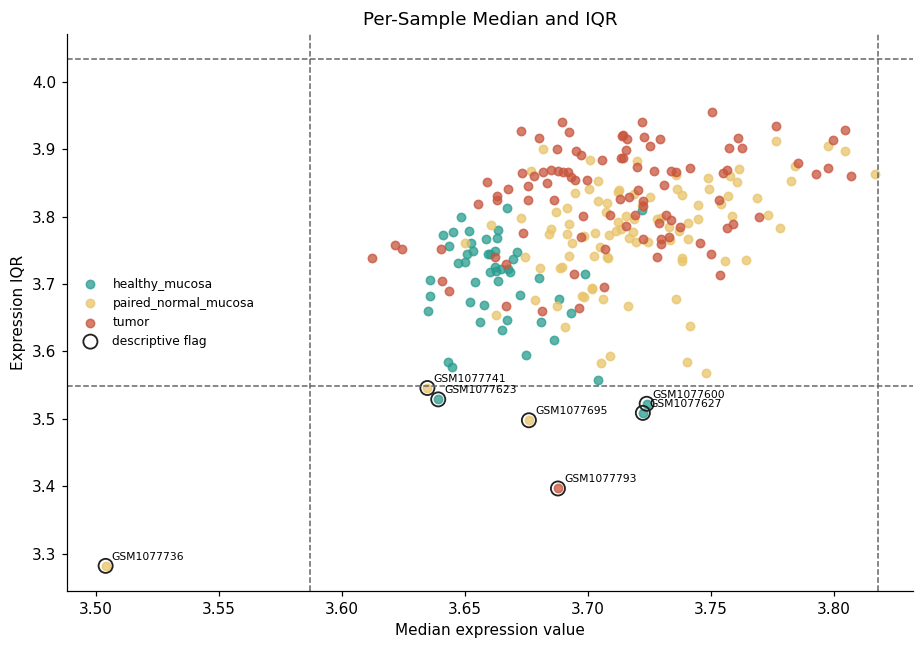

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 6))
for group in GROUP_ORDER:
    group_summary = sample_summary[sample_summary["group"] == group]
    ax.scatter(
        group_summary["median"],
        group_summary["iqr"],
        s=30,
        alpha=0.75,
        color=GROUP_COLORS[group],
        label=group,
    )

flagged = sample_summary[sample_summary["descriptive_flag"]]
ax.scatter(
    flagged["median"],
    flagged["iqr"],
    s=85,
    facecolors="none",
    edgecolors="#222222",
    linewidths=1.2,
    label="descriptive flag",
)
for accession, row in flagged.iterrows():
    ax.annotate(accession, (row["median"], row["iqr"]), xytext=(4, 4), textcoords="offset points", fontsize=7)

ax.axvline(median_lower, color="#666666", linestyle="--", linewidth=1)
ax.axvline(median_upper, color="#666666", linestyle="--", linewidth=1)
ax.axhline(iqr_lower, color="#666666", linestyle="--", linewidth=1)
ax.axhline(iqr_upper, color="#666666", linestyle="--", linewidth=1)
ax.set_title("Per-Sample Median and IQR")
ax.set_xlabel("Median expression value")
ax.set_ylabel("Expression IQR")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "sample_median_vs_iqr.png", dpi=180, bbox_inches="tight")
plt.show()

## Readiness for a First Exploratory PCA

The aligned matrix has no missing numeric values, a compact continuous value scale, and broadly comparable sample medians and IQRs. These observations are consistent with a matrix that may be suitable for a first exploratory PCA.

Before proceeding, the GEO processing notes and platform annotation should be checked, and the descriptively flagged samples should be reviewed alongside technical metadata. Any PCA should retain the paired study design in its interpretation and should not be treated as evidence of biological separation on its own.